In [1]:
!pip install zarr==2.8.3 'sunpy[all]' s3fs 'numpy<2' dask natsort

In [1]:
import os
import s3fs
import zarr
import dask.array as da
import numpy as np
from natsort import natsorted

import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm

# Load Data

In [2]:
# fix from https://github.com/SDOML/SDOMLv2/issues/3
AWS_ZARR_ROOT = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2_small.zarr/"

def s3_connection(path_to_zarr: os.path):
    """
    Instantiate connection to aws for a given path `path_to_zarr`
    """
    return s3fs.S3Map(
        root=path_to_zarr,
        s3=s3fs.S3FileSystem(anon=True),
        # anonymous access requires no credentials
        check=False,
    )
    
def load_single_aws_zarr(
    path_to_zarr: os.path,
    cache_max_single_size: int = None,
):
    """
    load zarr from s3 using LRU cache
    """
    return zarr.open(
        zarr.LRUStoreCache(
            store=s3_connection(path_to_zarr),
            max_size=cache_max_single_size,
        ),
        mode="r",
    )

In [3]:
# Using `root.tree()`, we are able to display the hierarchy (of `loc`).
root = load_single_aws_zarr(
    path_to_zarr=AWS_ZARR_ROOT,
)


print(root.tree())

/
 ├── .zgroup () |S24
 └── 2010
     ├── 131A (6135, 512, 512) float32
     ├── 1600A (6136, 512, 512) float32
     ├── 1700A (6135, 512, 512) float32
     ├── 171A (6135, 512, 512) float32
     ├── 193A (6135, 512, 512) float32
     ├── 211A (6136, 512, 512) float32
     ├── 304A (6134, 512, 512) float32
     ├── 335A (6135, 512, 512) float32
     └── 94A (6136, 512, 512) float32


# Inspect Data

In [4]:
data = root["2010"]["171A"]

In [5]:
all_image = da.from_array(data)
all_image

dask.array<array, shape=(6135, 512, 512), dtype=float32, chunksize=(120, 512, 512), chunktype=numpy.ndarray>

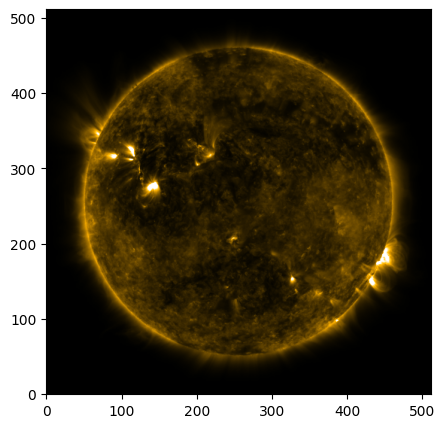

In [98]:
image=all_image[0,:,:]
plt.figure(figsize=(5,5))
colormap = plt.get_cmap('sdoaia171')
plt.imshow(image,origin='lower',vmin=10,vmax=1000,cmap=colormap)

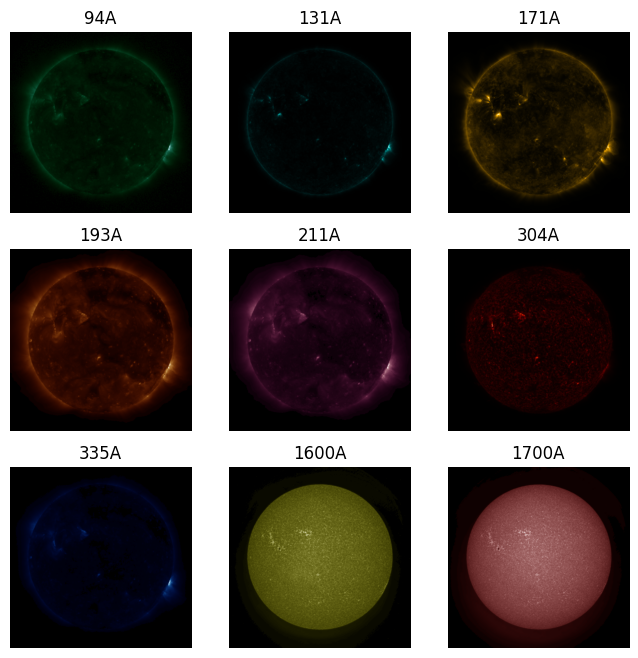

In [99]:
keys = natsorted(root["2010"].keys())
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, key in zip(axes.ravel(), keys):
    data = root["2010"][key][0]
    img = da.from_array(data)
    cmap = plt.get_cmap(f'sdoaia{key[:-1]}')
    im = ax.imshow(img, origin='lower', cmap=cmap)
    # fig.colorbar(im, ax=ax)
    ax.set_title(key)
    ax.axis('off')

plt.show()

In [106]:
data = root["2010"]["171A"]
sorted(data.attrs) # http://jsoc.stanford.edu/~jsoc/keywords/AIA/AIA02840_K_AIA-SDO_FITS_Keyword_Document.pdf

['ACS_CGT',
 'ACS_ECLP',
 'ACS_MODE',
 'ACS_SAFE',
 'ACS_SUNP',
 'AECDELAY',
 'AECMODE',
 'AECTYPE',
 'AGT1SVY',
 'AGT1SVZ',
 'AGT2SVY',
 'AGT2SVZ',
 'AGT3SVY',
 'AGT3SVZ',
 'AGT4SVY',
 'AGT4SVZ',
 'AIAECENF',
 'AIAECTI',
 'AIAGP1',
 'AIAGP10',
 'AIAGP2',
 'AIAGP3',
 'AIAGP4',
 'AIAGP5',
 'AIAGP6',
 'AIAGP7',
 'AIAGP8',
 'AIAGP9',
 'AIAHFSN',
 'AIASEN',
 'AIAWVLEN',
 'AICFGDL1',
 'AICFGDL2',
 'AICFGDL3',
 'AICFGDL4',
 'AIFCPS',
 'AIFDBID',
 'AIFILTYP',
 'AIFOENFL',
 'AIFRMLID',
 'AIFTSID',
 'AIFTSWTH',
 'AIFWEN',
 'AIHIS192',
 'AIHIS348',
 'AIHIS604',
 'AIHIS860',
 'AIHISMXB',
 'AIMGFSN',
 'AIMGOTS',
 'AIMGOTSS',
 'AIMGSHCE',
 'AIMGSHEN',
 'AIMGTYP',
 'AIMSHCBC',
 'AIMSHCBE',
 'AIMSHCTC',
 'AIMSHCTE',
 'AIMSHOBC',
 'AIMSHOBE',
 'AIMSHOTC',
 'AIMSHOTE',
 'AISTATE',
 'AIVNMST',
 'ASD_REC',
 'ASQFSN',
 'ASQHDR',
 'ASQTNUM',
 'BITPIX',
 'BLANK',
 'BSCALE',
 'BZERO',
 'CAMERA',
 'CAR_ROT',
 'CDELT1',
 'CDELT2',
 'CHECKSUM',
 'COMMENT',
 'CRLN_OBS',
 'CRLT_OBS',
 'CROTA2',
 'CRPIX1',
 'CRPIX

In [110]:
exptime = np.array(data.attrs["EXPTIME"])

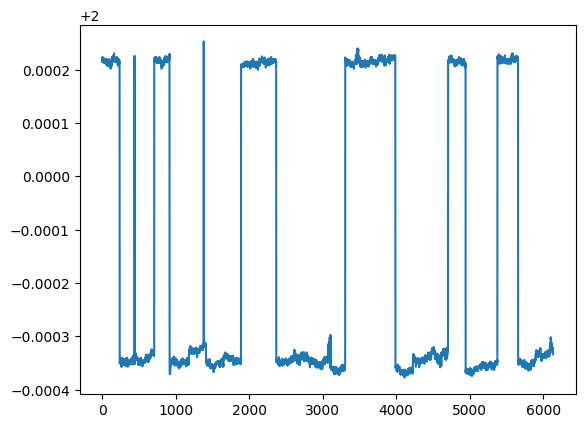

In [111]:
plt.plot(exptime)

In [114]:
# select indices where the exposure time is less than 2 seconds
selected_images = da.from_array(data)[exptime < 2.0]

In [115]:
selected_images

dask.array<getitem, shape=(4005, 512, 512), dtype=float32, chunksize=(144, 512, 512), chunktype=numpy.ndarray>

In [116]:
ds256 = selected_images[:10, ::2, ::2]
ds128 = selected_images[:10, ::4, ::4]
ds128

dask.array<getitem, shape=(10, 128, 128), dtype=float32, chunksize=(10, 128, 128), chunktype=numpy.ndarray>

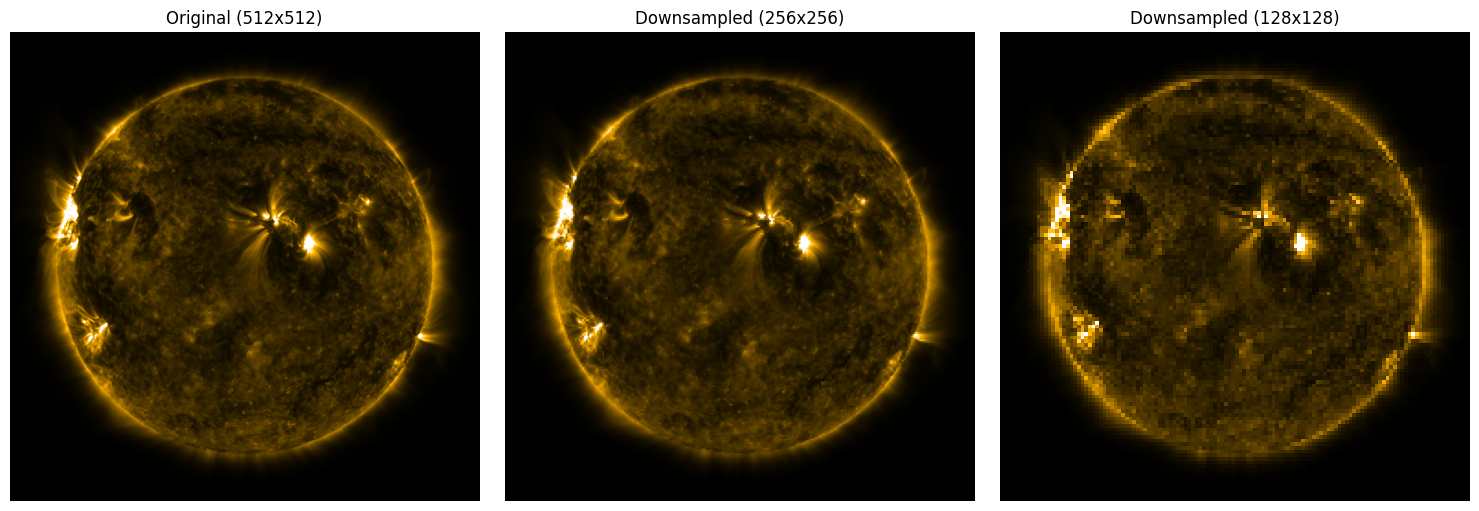

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colormap = plt.get_cmap('sdoaia171')

# List of images and titles for display
images = [selected_images, ds256, ds128]
titles = ['Original (512x512)', 'Downsampled (256x256)', 'Downsampled (128x128)']

# Loop over the axes to display each image
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img[0], origin='lower', vmin=10, vmax=1000, cmap=colormap)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Fun Times

In [119]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 5.5 MB/s eta 0:00:005.4 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 7.3 MB/s eta 0:00:007.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 7.3 MB/s eta 0:00:00


## Create Dataset

In [4]:
from torch.utils.data import Dataset, random_split, DataLoader

In [12]:
class SolarDataset(Dataset):
    def __init__(self, zarr_file):
        self.data = zarr_file['2010']
        all_channels = []
        for key in natsorted(self.data.keys()):
            d = da.from_array(self.data[key], chunks=(64,512,512))[:6130, ::4, ::4].persist()
            all_channels.append(d)
            print(d.shape)
            break
        self.all_channels = da.stack(all_channels, axis=0)
        self.X = self.all_channels[:5]
        self.Y = self.all_channels[5:]


    def __len__(self):
        return self.X.shape[1]

    def __getitem__(self, idx):
        x = self.X[:, idx, :, :]
        y = self.Y[:, idx, :, :]
        return x, y

In [16]:
da.from_array(root['2010']['171A'], chunks=(1,512,512))[:,::2,::2].persist()

KeyboardInterrupt: 

In [13]:
dataset = SolarDataset(root)
train_set, test_set, val_set = random_split(dataset, [0.5, 0.25, 0.25])

(6130, 128, 128)


In [75]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=True)

In [76]:
train_features, train_targset = next(iter(train_loader))

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'dask.array.core.Array'>